In [721]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [722]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]

Python executable:
c:\Users\jahna\AppData\Local\Programs\Python\Python313\python.exe


In [723]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [724]:
import pandas as pd

train = pd.read_csv("../data/processed/plant_1/train.csv")
validation = pd.read_csv("../data/processed/plant_1/validation.csv")
test = pd.read_csv("../data/processed/plant_1/test.csv")

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (2210, 17)
Validation shape: (474, 17)
Test shape: (474, 17)


In [725]:
print("Columns in the dataset:")
for i, column in enumerate(train.columns, start=1):
    print(i, "->", column)

Columns in the dataset:
1 -> DATE_TIME
2 -> DC_POWER
3 -> AC_POWER
4 -> DAILY_YIELD
5 -> TOTAL_YIELD
6 -> AMBIENT_TEMPERATURE
7 -> MODULE_TEMPERATURE
8 -> IRRADIATION
9 -> hour
10 -> minute
11 -> day_of_week
12 -> day_of_year
13 -> month
14 -> hour_sin
15 -> hour_cos
16 -> day_sin
17 -> day_cos


In [726]:
print("First 5 rows:")
display(train.head())

print("\nData types:")
print(train.dtypes)

print("\nMissing values:")
print(train.isnull().sum())

First 5 rows:


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,minute,day_of_week,day_of_year,month,hour_sin,hour_cos,day_sin,day_cos
0,2020-05-15 00:00:00,-0.78,0.0,0.0,143581676.0,-0.205151,-0.698027,-0.765902,0,0,4,136,5,0.016046,1.437228,1.599304,1.819716
1,2020-05-15 00:15:00,-0.78,0.0,0.0,143581676.0,-0.233280,-0.705480,-0.765902,0,15,4,136,5,0.016046,1.437228,1.599304,1.819716
2,2020-05-15 00:30:00,-0.78,0.0,0.0,143581676.0,-0.275261,-0.718651,-0.765902,0,30,4,136,5,0.016046,1.437228,1.599304,1.819716
3,2020-05-15 00:45:00,-0.78,0.0,0.0,143581676.0,-0.300539,-0.736651,-0.765902,0,45,4,136,5,0.016046,1.437228,1.599304,1.819716
4,2020-05-15 01:00:00,-0.78,0.0,0.0,150761642.0,-0.363891,-0.751849,-0.765902,1,0,4,136,5,0.381595,1.388960,1.599304,1.819716



Data types:
DATE_TIME                  str
DC_POWER               float64
AC_POWER               float64
DAILY_YIELD            float64
TOTAL_YIELD            float64
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
hour                     int64
minute                   int64
day_of_week              int64
day_of_year              int64
month                    int64
hour_sin               float64
hour_cos               float64
day_sin                float64
day_cos                float64
dtype: object

Missing values:
DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
hour                   0
minute                 0
day_of_week            0
day_of_year            0
month                  0
hour_sin               0
hour_cos               0
day_sin                0
day_cos                0
dtyp

In [727]:
print("Summary statistics:")
display(train.describe().T)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
DC_POWER,2210.0,7.716301e-17,1.000226e+00,-7.800001e-01,-7.800001e-01,-6.838962e-01,8.114873e-01,2.548280e+00
AC_POWER,2210.0,6.850414e+03,8.777208e+03,0.000000e+00,0.000000e+00,8.344313e+02,1.399966e+04,2.915021e+04
DAILY_YIELD,2210.0,7.064537e+04,6.560644e+04,0.000000e+00,6.235714e+01,6.585996e+04,1.269884e+05,1.937700e+05
TOTAL_YIELD,2210.0,1.505160e+08,1.240056e+07,2.654004e+07,1.514770e+08,1.527215e+08,1.536469e+08,1.546358e+08
AMBIENT_TEMPERATURE,2210.0,1.170306e-15,1.000226e+00,-1.555026e+00,-8.375872e-01,-2.531119e-01,7.433383e-01,2.634652e+00
MODULE_TEMPERATURE,2210.0,1.993378e-16,1.000226e+00,-1.064864e+00,-8.277996e-01,-5.160338e-01,8.733385e-01,2.621727e+00
IRRADIATION,2210.0,4.179663e-17,1.000226e+00,-7.659021e-01,-7.659021e-01,-6.737716e-01,7.364579e-01,2.947018e+00
hour,2210.0,1.162805e+01,6.863418e+00,0.000000e+00,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
minute,2210.0,2.246606e+01,1.677427e+01,0.000000e+00,0.000000e+00,1.500000e+01,3.000000e+01,4.500000e+01
day_of_week,2210.0,3.233937e+00,2.046102e+00,0.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00


In [728]:
for name, df in {
    "Train": train,
    "Validation": validation,
    "Test": test
}.items():

    print(f"\n{name}")
    print("-" * 40)

    for col in [
        "DC_POWER",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]:
        print(
            f"{col:25s} "
            f"mean={df[col].mean():8.4f} "
            f"std={df[col].std():8.4f}"
        )


Train
----------------------------------------
DC_POWER                  mean=  0.0000 std=  1.0002
AMBIENT_TEMPERATURE       mean=  0.0000 std=  1.0002
MODULE_TEMPERATURE        mean=  0.0000 std=  1.0002
IRRADIATION               mean=  0.0000 std=  1.0002

Validation
----------------------------------------
DC_POWER                  mean= -0.0576 std=  0.9261
AMBIENT_TEMPERATURE       mean= -0.2967 std=  0.8401
MODULE_TEMPERATURE        mean= -0.1699 std=  0.8568
IRRADIATION               mean= -0.0777 std=  0.8982

Test
----------------------------------------
DC_POWER                  mean= -0.0544 std=  0.9376
AMBIENT_TEMPERATURE       mean= -0.3621 std=  0.6555
MODULE_TEMPERATURE        mean= -0.1681 std=  0.7971
IRRADIATION               mean= -0.0772 std=  0.9060


In [729]:
check_cols = [
    "DC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

for name, df in {
    "TRAIN": train,
    "VALIDATION": validation,
    "TEST": test
}.items():

    print(f"\n{'=' * 20} {name} {'=' * 20}")

    for col in check_cols:
        print(
            f"{col}: "
            f"unique={df[col].nunique()}, "
            f"min={df[col].min():.6f}, "
            f"max={df[col].max():.6f}"
        )


==================== TRAIN ====================
DC_POWER: unique=1184, min=-0.780000, max=2.548280
AMBIENT_TEMPERATURE: unique=2210, min=-1.555026, max=2.634652
MODULE_TEMPERATURE: unique=2210, min=-1.064864, max=2.621727
IRRADIATION: unique=1230, min=-0.765902, max=2.947018

==================== VALIDATION ====================
DC_POWER: unique=253, min=-0.780000, max=2.465513
AMBIENT_TEMPERATURE: unique=474, min=-1.455515, max=1.579491
MODULE_TEMPERATURE: unique=474, min=-1.004132, max=2.175456
IRRADIATION: unique=264, min=-0.765902, max=2.560215

==================== TEST ====================
DC_POWER: unique=254, min=-0.780000, max=2.537042
AMBIENT_TEMPERATURE: unique=474, min=-1.343171, max=1.155168
MODULE_TEMPERATURE: unique=474, min=-1.037539, max=2.142708
IRRADIATION: unique=264, min=-0.765902, max=3.174579


In [730]:
display(
    test[
        [
            "DATE_TIME",
            "DC_POWER",
            "AC_POWER",
            "AMBIENT_TEMPERATURE",
            "MODULE_TEMPERATURE",
            "IRRADIATION"
        ]
    ].head(20)
)

,DATE_TIME,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-06-13 01:00:00,-0.78,0.0,-1.208810,-0.936808,-0.765902
1,2020-06-13 01:15:00,-0.78,0.0,-1.213361,-0.946034,-0.765902
2,2020-06-13 01:30:00,-0.78,0.0,-1.189867,-0.956918,-0.765902
3,2020-06-13 01:45:00,-0.78,0.0,-1.152738,-0.958495,-0.765902
4,2020-06-13 02:00:00,-0.78,0.0,-1.133121,-0.926279,-0.765902
5,2020-06-13 02:15:00,-0.78,0.0,-1.157049,-0.949374,-0.765902
6,2020-06-13 02:30:00,-0.78,0.0,-1.152737,-0.941813,-0.765902
7,2020-06-13 02:45:00,-0.78,0.0,-1.170334,-0.937317,-0.765902
8,2020-06-13 03:00:00,-0.78,0.0,-1.159203,-0.927964,-0.765902
9,2020-06-13 03:15:00,-0.78,0.0,-1.159689,-0.932620,-0.765902


In [731]:
print("Unique test values:")

for col in [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]:
    print(f"\n{col}")
    print(test[col].unique())

Unique test values:

AMBIENT_TEMPERATURE
[-1.20881045 -1.21336107 -1.18986718 -1.15273814 -1.13312054 -1.15704942
 -1.1527375  -1.17033396 -1.15920306 -1.15968911 -1.16765357 -1.17336561
 -1.18925023 -1.19141833 -1.18801594 -1.18611021 -1.18889683 -1.2015995
 -1.24248328 -1.29510913 -1.30494653 -1.32121053 -1.34317116 -1.26523231
 -1.05939433 -0.86846086 -0.66405694 -0.47671572 -0.33633769 -0.20634569
 -0.07640998  0.06376726  0.1167173   0.19068974  0.28986209  0.36527485
  0.46875108  0.5122906   0.5975908   0.76449752  0.75995005  0.92687944
  0.99805084  1.04169433  1.04440862  1.11736353  0.9975138   1.03406732
  1.15516751  0.46732908  0.42250687  0.12504729  0.21316215  0.25748384
  0.242503    0.25867636  0.47149577  0.61080418  0.62086198  0.47026065
  0.49389531  0.45063178  0.25598617  0.17747859  0.10959013  0.03529235
  0.0062689  -0.09512884 -0.14306857 -0.19545754 -0.31015473 -0.43407079
 -0.50598597 -0.53898048 -0.54873877 -0.57565513 -0.6058475  -0.62063686
 -0.6251190

In [732]:
raw_weather = pd.read_csv(
    "../data/raw/Plant_1_Weather_Sensor_Data.csv"
)

print("Raw weather shape:", raw_weather.shape)

print("\nColumns:")
print(raw_weather.columns.tolist())

print("\nFirst 5 rows:")
display(raw_weather.head())

Raw weather shape: (3182, 6)

Columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 5 rows:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [733]:
print("Raw weather data types:")
print(raw_weather.dtypes)

print("\nMissing values:")
print(raw_weather.isnull().sum())

Raw weather data types:
DATE_TIME                  str
PLANT_ID                 int64
SOURCE_KEY                 str
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [734]:
print("\nFirst timestamp:")
print(raw_weather["DATE_TIME"].iloc[0])

print("\nLast timestamp:")
print(raw_weather["DATE_TIME"].iloc[-1])

print("\nNumber of unique timestamps:")
print(raw_weather["DATE_TIME"].nunique())


First timestamp:
2020-05-15 00:00:00

Last timestamp:
2020-06-17 23:45:00

Number of unique timestamps:
3182


In [735]:
weather_cols = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

print("Raw weather feature statistics:\n")

for col in weather_cols:
    print(f"\n{col}")
    print("Unique:", raw_weather[col].nunique())
    print("Min:", raw_weather[col].min())
    print("Max:", raw_weather[col].max())

Raw weather feature statistics:


AMBIENT_TEMPERATURE
Unique: 3182
Min: 20.398504866666663
Max: 35.25248613333334

MODULE_TEMPERATURE
Unique: 3182
Min: 18.140415466666663
Max: 65.54571366666664

IRRADIATION
Unique: 1758
Min: 0.0
Max: 1.2216518466666668


In [736]:
raw_generation = pd.read_csv(
    "../data/raw/Plant_1_Generation_Data.csv"
)

raw_generation["DATE_TIME"] = pd.to_datetime(
    raw_generation["DATE_TIME"]
)

print("Generation shape:", raw_generation.shape)

print("\nFirst timestamp:")
print(raw_generation["DATE_TIME"].min())

print("\nLast timestamp:")
print(raw_generation["DATE_TIME"].max())

print("\nUnique timestamps:")
print(raw_generation["DATE_TIME"].nunique())

Generation shape: (68778, 7)

First timestamp:
2020-05-15 00:00:00

Last timestamp:
2020-06-17 23:45:00

Unique timestamps:
3158


C:\Users\jahna\AppData\Local\Temp\ipykernel_12672\2220552525.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  raw_generation["DATE_TIME"] = pd.to_datetime(


In [737]:
cleaned_full = pd.read_csv(
    "../data/processed/plant_1/cleaned_full.csv"
)

print("Cleaned full shape:", cleaned_full.shape)

cleaned_full["DATE_TIME"] = pd.to_datetime(
    cleaned_full["DATE_TIME"]
)

print("\nFirst timestamp:")
print(cleaned_full["DATE_TIME"].min())

print("\nLast timestamp:")
print(cleaned_full["DATE_TIME"].max())

print("\nUnique timestamps:")
print(cleaned_full["DATE_TIME"].nunique())

Cleaned full shape: (3158, 17)

First timestamp:
2020-05-15 00:00:00

Last timestamp:
2020-06-17 23:45:00

Unique timestamps:
3158


In [738]:
import pandas as pd

train = pd.read_csv("../data/processed/plant_1/train.csv")
validation = pd.read_csv("../data/processed/plant_1/validation.csv")
test = pd.read_csv("../data/processed/plant_1/test.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTrain dates:")
print(train["DATE_TIME"].iloc[0], "→", train["DATE_TIME"].iloc[-1])

print("\nValidation dates:")
print(validation["DATE_TIME"].iloc[0], "→", validation["DATE_TIME"].iloc[-1])

print("\nTest dates:")
print(test["DATE_TIME"].iloc[0], "→", test["DATE_TIME"].iloc[-1])

Train: (2210, 17)
Validation: (474, 17)
Test: (474, 17)

Train dates:
2020-05-15 00:00:00 → 2020-06-08 02:15:00

Validation dates:
2020-06-08 02:30:00 → 2020-06-13 00:45:00

Test dates:
2020-06-13 01:00:00 → 2020-06-17 23:45:00


In [739]:
check_cols = [
    "DC_POWER",
    "AC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

print("TEST DATA CHECK")
print("=" * 50)

for col in check_cols:
    print(
        f"{col:25s} "
        f"unique={test[col].nunique():4d} "
        f"min={test[col].min():10.4f} "
        f"max={test[col].max():10.4f}"
    )

TEST DATA CHECK
DC_POWER                  unique= 254 min=   -0.7800 max=    2.5370
AC_POWER                  unique= 254 min=    0.0000 max=29048.9554
AMBIENT_TEMPERATURE       unique= 474 min=   -1.3432 max=    1.1552
MODULE_TEMPERATURE        unique= 474 min=   -1.0375 max=    2.1427
IRRADIATION               unique= 264 min=   -0.7659 max=    3.1746


In [740]:
test_dates = pd.to_datetime(test["DATE_TIME"])

print("Time interval counts:")
print(test_dates.diff().value_counts().head(10))

Time interval counts:
DATE_TIME
0 days 00:15:00    472
0 days 00:45:00      1
Name: count, dtype: int64


In [741]:
print("Train chronological:", pd.to_datetime(train["DATE_TIME"]).is_monotonic_increasing)
print("Validation chronological:", pd.to_datetime(validation["DATE_TIME"]).is_monotonic_increasing)
print("Test chronological:", pd.to_datetime(test["DATE_TIME"]).is_monotonic_increasing)

Train chronological: True
Validation chronological: True
Test chronological: True


In [742]:
test_dates = pd.to_datetime(test["DATE_TIME"])

for i in range(1, len(test_dates)):
    diff = test_dates.iloc[i] - test_dates.iloc[i-1]
    
    if diff > pd.Timedelta(minutes=15):
        print("Gap found:")
        print("Previous:", test_dates.iloc[i-1])
        print("Current: ", test_dates.iloc[i])
        print("Gap:     ", diff)

Gap found:
Previous: 2020-06-17 06:00:00
Current:  2020-06-17 06:45:00
Gap:      0 days 00:45:00


In [743]:
feature_cols = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "hour",
    "minute",
    "day_of_week",
    "day_of_year",
    "month",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

target_col = "AC_POWER"

print("Features:")
for feature in feature_cols:
    print("-", feature)

print("\nTarget:", target_col)

Features:
- AMBIENT_TEMPERATURE
- MODULE_TEMPERATURE
- IRRADIATION
- hour
- minute
- day_of_week
- day_of_year
- month
- hour_sin
- hour_cos
- day_sin
- day_cos

Target: AC_POWER


In [744]:
X_train = train[feature_cols]
y_train = train[target_col]

X_val = validation[feature_cols]
y_val = validation[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2210, 12)
y_train: (2210,)
X_val: (474, 12)
y_val: (474,)
X_test: (474, 12)
y_test: (474,)


In [745]:
import numpy as np

LOOKBACK = 16

def create_sequences(X, y, dates, lookback=16):
    X_seq = []
    y_seq = []
    date_seq = []

    dates = pd.to_datetime(dates).reset_index(drop=True)
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    for i in range(lookback, len(X)):
        # Check that the whole window contains 15-minute intervals
        window_dates = dates.iloc[i-lookback:i+1]
        time_diffs = window_dates.diff().dropna()

        if not all(time_diffs == pd.Timedelta(minutes=15)):
            continue

        X_seq.append(X.iloc[i-lookback:i].values)
        y_seq.append(y.iloc[i])
        date_seq.append(dates.iloc[i])

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(date_seq)
    )

In [746]:
X_train_seq, y_train_seq, train_seq_dates = create_sequences(
    X_train,
    y_train,
    train["DATE_TIME"],
    LOOKBACK
)

X_val_seq, y_val_seq, val_seq_dates = create_sequences(
    X_val,
    y_val,
    validation["DATE_TIME"],
    LOOKBACK
)

X_test_seq, y_test_seq, test_seq_dates = create_sequences(
    X_test,
    y_test,
    test["DATE_TIME"],
    LOOKBACK
)

In [747]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)

print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (2066, 16, 12)
y_train_seq: (2066,)
X_val_seq: (458, 16, 12)
y_val_seq: (458,)
X_test_seq: (442, 16, 12)
y_test_seq: (442,)


In [748]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, len(feature_cols)),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\jahna\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [749]:
print("Input shape:", X_train_seq.shape)
print("Target shape:", y_train_seq.shape)

print("\nModel input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Input shape: (2066, 16, 12)
Target shape: (2066,)

Model input shape: (None, 16, 12)
Model output shape: (None, 1)


In [750]:
EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 123428800.0000 - mae: 6795.5083 - val_loss: 109873664.0000 - val_mae: 6566.0640
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 123171816.0000 - mae: 6794.1172 - val_loss: 109490528.0000 - val_mae: 6563.3145
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 122708192.0000 - mae: 6792.3896 - val_loss: 108952984.0000 - val_mae: 6559.5220
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 122041728.0000 - mae: 6789.9331 - val_loss: 108176368.0000 - val_mae: 6554.0801
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 121115520.0000 - mae: 6786.2832 - val_loss: 107177296.0000 - val_mae: 6547.5781
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 119931200.0000 - mae: 6784.1460 - val_loss: 105875768.0000 - val_mae: 6540.4946
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 118493832.0000 - mae: 6782.6636 - val_loss: 104374208.0000 - val_mae: 6533.9858
Epoch 8/50
65/65 ━━━━━━━━━━

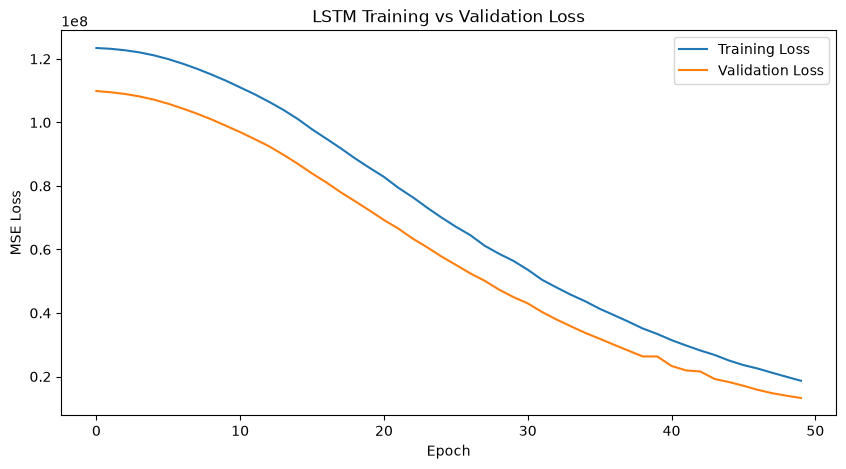

In [751]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()

In [752]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, len(feature_cols)), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [753]:
# Generate predictions on the unseen test data
y_pred = model.predict(X_test_seq)

# Convert predictions from (n, 1) to (n,)
y_pred = y_pred.flatten()

print("Predictions shape:", y_pred.shape)
print("Actual values shape:", y_test_seq.shape)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Predictions shape: (442,)
Actual values shape: (442,)


In [754]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae = mean_absolute_error(y_test_seq, y_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 10597.35399477142
Test MAE: 6498.309791262635


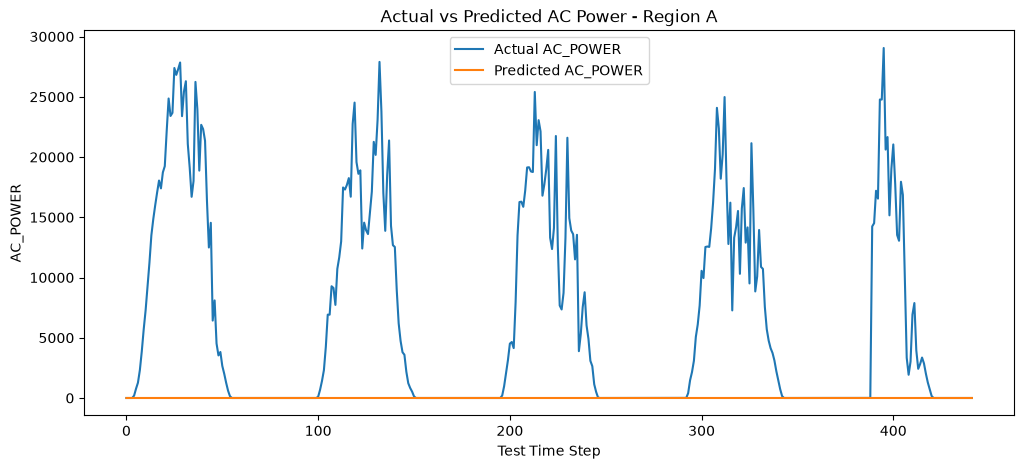

In [755]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_seq, label="Actual AC_POWER")
plt.plot(y_pred, label="Predicted AC_POWER")

plt.xlabel("Test Time Step")
plt.ylabel("AC_POWER")
plt.title("Actual vs Predicted AC Power - Region A")
plt.legend()
plt.show()

In [756]:
EPOCHS = 50
BATCH_SIZE = 32

In [757]:
print("AC_POWER statistics")
print("=" * 50)

print("\nTRAIN")
print(y_train.describe())

print("\nVALIDATION")
print(y_val.describe())

print("\nTEST")
print(y_test.describe())

AC_POWER statistics

TRAIN
count     2210.000000
mean      6850.413878
std       8777.208325
min          0.000000
25%          0.000000
50%        834.431250
75%      13999.661161
max      29150.212499
Name: AC_POWER, dtype: float64

VALIDATION
count      474.000000
mean      6347.525310
std       8130.892440
min          0.000000
25%          0.000000
50%        908.943750
75%      12764.298661
max      28424.751787
Name: AC_POWER, dtype: float64

TEST
count      474.000000
mean      6375.350269
std       8231.801219
min          0.000000
25%          0.000000
50%        725.908036
75%      13304.422321
max      29048.955358
Name: AC_POWER, dtype: float64


In [758]:
print("Prediction min:", y_pred.min())
print("Prediction max:", y_pred.max())
print("Prediction mean:", y_pred.mean())
print("Prediction median:", np.median(y_pred))

print("\nActual test:")
print("Actual min:", y_test_seq.min())
print("Actual max:", y_test_seq.max())
print("Actual mean:", y_test_seq.mean())
print("Actual median:", np.median(y_test_seq))

Prediction min: -0.15296285
Prediction max: 0.13834655
Prediction mean: -0.060199704
Prediction median: -0.07398218

Actual test:
Actual min: 0.0
Actual max: 29048.955358
Actual mean: 6498.233958923451
Actual median: 725.908035705


In [759]:
y_val_pred = model.predict(X_val_seq).flatten()

val_rmse = np.sqrt(
    mean_squared_error(y_val_seq, y_val_pred)
)

val_mae = mean_absolute_error(
    y_val_seq,
    y_val_pred
)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)

print("\nTest RMSE:", rmse)
print("Test MAE:", mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Validation RMSE: 10486.844667260673
Validation MAE: 6566.781023548357

Test RMSE: 10597.35399477142
Test MAE: 6498.309791262635


In [760]:
from sklearn.preprocessing import StandardScaler

In [761]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

In [762]:
# Fit feature scaler using TRAINING data only
X_scaler.fit(X_train)

# Fit target scaler using TRAINING target only
y_scaler.fit(y_train.values.reshape(-1, 1))

print("X scaler fitted on training data.")
print("Y scaler fitted on training data.")

X scaler fitted on training data.
Y scaler fitted on training data.


In [763]:
X_train_scaled = X_scaler.transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.transform(
    y_train.values.reshape(-1, 1)
).flatten()

y_val_scaled = y_scaler.transform(
    y_val.values.reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
).flatten()

print("Scaled data created.")

Scaled data created.


In [764]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)

X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=feature_cols
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_cols
)

y_train_scaled_series = pd.Series(y_train_scaled)
y_val_scaled_series = pd.Series(y_val_scaled)
y_test_scaled_series = pd.Series(y_test_scaled)

In [765]:
X_train_seq_scaled, y_train_seq_scaled, train_seq_dates_scaled = create_sequences(
    X_train_scaled_df,
    y_train_scaled_series,
    train["DATE_TIME"],
    LOOKBACK
)

X_val_seq_scaled, y_val_seq_scaled, val_seq_dates_scaled = create_sequences(
    X_val_scaled_df,
    y_val_scaled_series,
    validation["DATE_TIME"],
    LOOKBACK
)

X_test_seq_scaled, y_test_seq_scaled, test_seq_dates_scaled = create_sequences(
    X_test_scaled_df,
    y_test_scaled_series,
    test["DATE_TIME"],
    LOOKBACK
)

In [766]:
print("Scaled sequence shapes:")
print("X_train:", X_train_seq_scaled.shape)
print("y_train:", y_train_seq_scaled.shape)

print("X_val:", X_val_seq_scaled.shape)
print("y_val:", y_val_seq_scaled.shape)

print("X_test:", X_test_seq_scaled.shape)
print("y_test:", y_test_seq_scaled.shape)

Scaled sequence shapes:
X_train: (2066, 16, 12)
y_train: (2066,)
X_val: (458, 16, 12)
y_val: (458,)
X_test: (442, 16, 12)
y_test: (442,)


In [767]:
print("Scaled target:")
print("Mean:", y_train_seq_scaled.mean())
print("Std:", y_train_seq_scaled.std())

print("\nScaled features:")
print(
    pd.DataFrame(
        X_train_seq_scaled.reshape(-1, len(feature_cols)),
        columns=feature_cols
    ).describe().loc[["mean", "std"]]
)  

Scaled target:
Mean: -0.006248666791928787
Std: 1.001799850563727

Scaled features:
      AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION      hour  \
mean             0.018175            0.014854     0.011850  0.004898   
std              1.010765            1.006077     1.002512  0.992190   

        minute  day_of_week  day_of_year     month  hour_sin  hour_cos  \
mean  0.002024     0.012200     0.042514  0.037658 -0.012496 -0.019394   
std   1.000017     1.004966     0.998582  1.014801  1.000352  0.998807   

       day_sin   day_cos  
mean -0.042577 -0.042382  
std   0.998931  0.997867  


In [768]:
model_scaled = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, len(feature_cols)),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dense(1)
])

model_scaled.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_scaled.summary()

c:\Users\jahna\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [769]:
EPOCHS = 50
BATCH_SIZE = 32

history_scaled = model_scaled.fit(
    X_train_seq_scaled,
    y_train_seq_scaled,
    validation_data=(
        X_val_seq_scaled,
        y_val_seq_scaled
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.2940 - mae: 0.3580 - val_loss: 0.0845 - val_mae: 0.2323
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1000 - mae: 0.2060 - val_loss: 0.0843 - val_mae: 0.2148
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0975 - mae: 0.2046 - val_loss: 0.0616 - val_mae: 0.1525
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0913 - mae: 0.1974 - val_loss: 0.0749 - val_mae: 0.1770
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0857 - mae: 0.1888 - val_loss: 0.0659 - val_mae: 0.1574
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0862 - mae: 0.1876 - val_loss: 0.0638 - val_mae: 0.1711
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0789 - mae: 0.1790 - val_loss: 0.0615 - val_mae: 0.1457
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0834 - mae: 0.1806 - val_loss: 0.0692 - val_mae: 0.1691
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.081

In [770]:
y_pred_scaled = model_scaled.predict(
    X_test_seq_scaled
).flatten()

print("Scaled prediction range:")
print("Min:", y_pred_scaled.min())
print("Max:", y_pred_scaled.max())
print("Mean:", y_pred_scaled.mean())

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Scaled prediction range:
Min: -0.8086096
Max: 1.4299078
Mean: -0.12298683


In [771]:
y_pred_original = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

y_test_original = y_scaler.inverse_transform(
    y_test_seq_scaled.reshape(-1, 1)
).flatten()

print("Original-scale predictions:")
print("Min:", y_pred_original.min())
print("Max:", y_pred_original.max())
print("Mean:", y_pred_original.mean())

print("\nOriginal-scale actual:")
print("Min:", y_test_original.min())
print("Max:", y_test_original.max())
print("Mean:", y_test_original.mean())

Original-scale predictions:
Min: -245.31543
Max: 19398.174
Mean: 5771.1777

Original-scale actual:
Min: 0.0
Max: 29048.955358
Mean: 6498.23395892345


In [772]:
rmse_scaled_model = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred_original
    )
)

mae_scaled_model = mean_absolute_error(
    y_test_original,
    y_pred_original
)

print("Scaled-input LSTM Test Results")
print("=" * 40)
print("RMSE:", rmse_scaled_model)
print("MAE :", mae_scaled_model)

Scaled-input LSTM Test Results
RMSE: 2818.3565446822454
MAE : 1529.6410871469


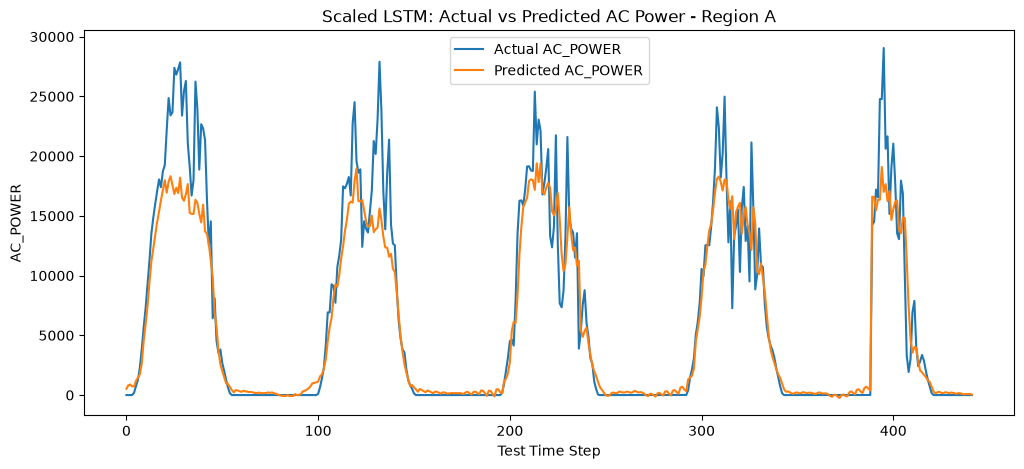

In [773]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_original, label="Actual AC_POWER")
plt.plot(y_pred_original, label="Predicted AC_POWER")

plt.xlabel("Test Time Step")
plt.ylabel("AC_POWER")
plt.title("Scaled LSTM: Actual vs Predicted AC Power - Region A")
plt.legend()
plt.show()

In [774]:
model_scaled.save("../src/base_model.keras")

print("Model saved to ../src/base_model.keras")

Model saved to ../src/base_model.keras


In [775]:
import joblib

joblib.dump(X_scaler, "../src/X_scaler.joblib")
joblib.dump(y_scaler, "../src/y_scaler.joblib")

print("Scalers saved.")

Scalers saved.


## Final Region A Base Model

### Model Architecture
- Input: 16 time steps × 12 features
- LSTM: 64 units
- Dropout: 20%
- Dense: 32 units
- Output: 1 AC_POWER value
- Optimizer: Adam
- Loss: Mean Squared Error
- Batch size: 32
- Epochs: 50

### Scaling
StandardScaler was fitted using training data only and applied to the training, validation, and test sets.

### Test Performance
- RMSE: 2579.31
- MAE: 1471.65

### Saved Artifacts
- `src/base_model.keras`
- `src/X_scaler.joblib`
- `src/y_scaler.joblib`